## Pandas - 05

## Merging, Joining & Concatenating

In [1]:
import numpy as np
import pandas as pd

In [2]:
courses =pd.read_csv("courses.csv")
students =pd.read_csv("students.csv")
nov = pd.read_csv("reg-month1.csv")
dec = pd.read_csv("reg-month2.csv")
matches =pd.read_csv("matches.csv")
delivery =pd.read_csv("deliveries.csv")





## Concatenating

In [4]:
# pd.concat() ---> concate  many dataframes pass in list (by default axis =0 vertically stacking)
# we can stack Vertically only equal  columns dataframes.
# igonre_index = True parameter ---> make new index and ignore the old ones
regs = pd.concat([nov,dec],ignore_index=True)
regs


,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [ ]:
# df.append()  # it is depricated now.


In [7]:
# keys parameter ->pd.concat()
#  multiindex Dataframe
multi = pd.concat([nov,dec],keys=["Nov","Dec"])
multi # it gives multiindex dataframe

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [ ]:
# indexing in multiindex dataframe
multi.loc["Nov"] # fetch Nov data
multi.loc["Dec"] # Dec data
multi.loc[("Nov",2)] # fetching Nov's 3rd row by gving both indices in tuple
multi.loc[("Dec",24)] # -> dec -> 25th -> row

student_id    11
course_id     10
Name: (Dec, 24), dtype: int64

In [ ]:
# horizontally concatenating ---> pd.concat() -->axis=1 ---> for horizontally stacking 
# we can stack horizontally also unequal and different columns dataframes
# resultant dataframe shape is of bigger dataframe shape (in terms of rows)
# first dataframe extra rows will get NaN values
# it is not useful as the vertical concatenating is.
pd.concat([nov,dec],axis=1)


,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


## Joining

In [ ]:
# joining ---> two or more dataframes to be joined on the basis of common column.

In [ ]:
# merge() --> how and on parameter

# inner join ---> it fetches only data and join it that is common on both tables.

students.merge(regs,how="inner",on="student_id") # students is left table and regs is right table

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [12]:
# left join ---> On the Basis of specific common column we can join --->it fetches and join the data that is common to both but also the data that is in the left table but not in the right table.
courses.merge(regs,how="left",on="course_id")


,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [107]:
# adding more students in students dataframe through concatenating..
temp_df= pd.DataFrame({
    "student_id": [26,27,28],
    "name": ["Hammad","Haider","Huzaifa"],
    "partner": [28,26,17]
})
students = pd.concat([students,temp_df],ignore_index=True)
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [ ]:
# right join -->  On the Basis of specific common  we can join --->it fetches and join the data that is common to both but also the data that is in the right table but not in the left table.
students.merge(regs,how="right",on="student_id")


,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [4]:
# outer join -->  On the Basis of specific common column we can join --->it fetches and join the data that is common to both but also different will be joined first the left table different data is joined then the right table different data is joined.
students.merge(regs,how = "outer",on="student_id").tail(10)

,student_id,name,partner,course_id
50,23,Chhavi Lachman,18.0,3.0
51,23,Chhavi Lachman,18.0,6.0
52,23,Chhavi Lachman,18.0,9.0
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,38,NaN,NaN,1.0
58,42,NaN,NaN,9.0
59,50,NaN,NaN,8.0


## Questions

In [5]:
# find total renvenue generated.
total= regs.merge(courses,how="inner",on="course_id")
print(f"The Total Revenue Generated in Nov & Dec is: {total["price"].sum()}")


The Total Revenue Generated in Nov & Dec is: 154247


In [6]:
nov.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [7]:
dec.head()

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9


In [19]:
# find month by month revenue.
temp_df = pd.concat([nov,dec],keys=["Nov","Dec"]).reset_index()
temp_df


,level_0,level_1,student_id,course_id
0,Nov,0,23,1
1,Nov,1,15,5
2,Nov,2,18,6
3,Nov,3,23,4
4,Nov,4,16,9
5,Nov,5,18,1
6,Nov,6,1,1
7,Nov,7,7,8
8,Nov,8,22,3
9,Nov,9,15,1


In [22]:
df = temp_df.merge(courses,how="inner",on="course_id")
df

,level_0,level_1,student_id,course_id,course_name,price
0,Nov,0,23,1,python,2499
1,Nov,1,15,5,tableau,2499
2,Nov,2,18,6,power bi,1899
3,Nov,3,23,4,machine learning,9999
4,Nov,4,16,9,plotly,699
5,Nov,5,18,1,python,2499
6,Nov,6,1,1,python,2499
7,Nov,7,7,8,pandas,1099
8,Nov,8,22,3,data analysis,4999
9,Nov,9,15,1,python,2499


In [23]:
df.groupby("level_0")["price"].sum()

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

In [24]:
regs.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [27]:
# 3: print the registration table
# cols --> name --> course ---> price
temp_df= regs.merge(students,how="left", on="student_id")
temp_df
reg_table = temp_df.merge(courses,how="left",on="course_id")[["name","course_name","price"]]
reg_table

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='coursename', ylabel='revenue'>

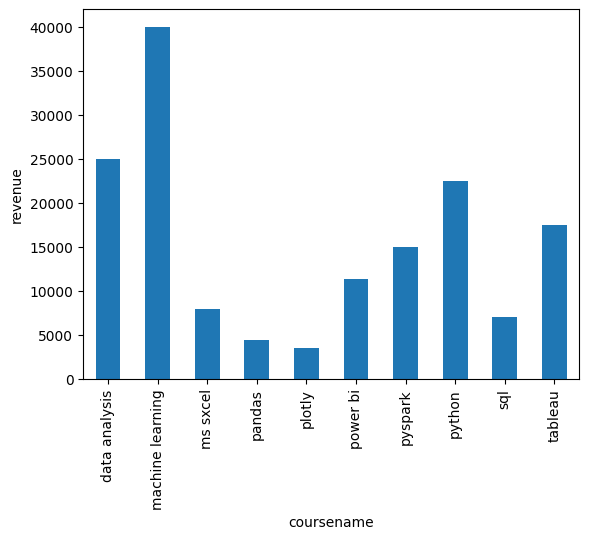

In [28]:
# 4: plot bar chart for renvenue of each course.
revenue= regs.merge(courses,how="left",on="course_id").groupby("course_name")["price"].sum()
revenue.plot(kind="bar",xlabel= "coursename",ylabel="revenue")

In [ ]:
# 5: find students who enrolled in both the months.
# My logic
common_students = pd.DataFrame(np.intersect1d(nov["student_id"],dec["student_id"]),columns=["student_id"])
common_students.merge(students,how="left",on="student_id")

,student_id,name,partner
0,1,Kailash Harjo,23
1,3,Parveen Bhalla,3
2,7,Tarun Thaker,9
3,11,David Mukhopadhyay,20
4,16,Elias Dodiya,25
5,17,Yasmin Palan,7
6,18,Fardeen Mahabir,13
7,22,Yash Sethi,21
8,23,Chhavi Lachman,18


In [75]:
# Actual
common_students_id = np.intersect1d(nov["student_id"],dec["student_id"])
students[students["student_id"].isin(common_students_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [ ]:
#6: find course that got no enrollment.
# My Logic
temp_df = courses.merge(regs,how="left", on = "course_id")
temp_df[temp_df["student_id"].isnull()]["course_name"]

53    Numpy
54      C++
Name: course_name, dtype: str

In [95]:
# another method
courses["course_id"]
regs["course_id"]
course_id_list= np.setdiff1d(courses["course_id"],regs["course_id"])
courses[courses["course_id"].isin(course_id_list)]["course_name"]

10    Numpy
11      C++
Name: course_name, dtype: str

In [ ]:
# 7: a). find students who did not enroll into any course.
# students["student_id"]
regs["student_id"]
student_notenroll_list = np.setdiff1d(students["student_id"],regs["student_id"])
students_not_enroll = students[students["student_id"].isin(student_notenroll_list)]
students_not_enroll



,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11
25,26,Hammad,28
26,27,Haider,26
27,28,Huzaifa,17


In [ ]:
# b). find how many students did not enroll into any course.
students_not_enroll.shape[0]

10

In [119]:
# c). find the percentage of students did not enroll into any course
total= students.shape[0] # total students
not_enroll = student_notenroll_list.shape[0] # not enroll into any course students
percentage = (not_enroll/total) * 100
print(f"{np.round(percentage,2)}% students did not enroll into any course.")

35.71% students did not enroll into any course.


In [122]:
# d). find the percentage of students that enroll into any course
percent= 100 - percentage
print(f"{np.round(percent,2)}% students enroll into any course.")

64.29% students enroll into any course.


In [ ]:
# self join ---> join two same tables  by giving two columns for each.
# syntax ---> left_table.merge(right_table,how = "inner", left_on="column_name",right_on="column_name")


In [126]:
# 8: print table 
# cols ---> student name --> partner name
students.merge(students,how="inner",left_on="partner",right_on="student_id")[["name_x","name_y"]].rename(columns={"name_x":"Name","name_y":"Partner"})

,Name,Partner
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [ ]:
# 9: find top 3 students who did most number enrollments.
regs.merge(students,how="inner",on="student_id")["name"].value_counts().head(3) # there is a problem in this apporach we did value_counts on name column but it could be there that different persons have same name therefore it counts different name occurances at once this is not the better approach,

name
Chhavi Lachman    6
Tarun Thaker      5
Elias Dodiya      4
Name: count, dtype: int64

In [17]:
# actual method
regs.merge(students,how="inner",on="student_id").groupby(["student_id","name"])["course_id"].count().sort_values(ascending =False).head(3)

student_id  name            
23          Chhavi Lachman      6
7           Tarun Thaker        5
14          Pranab Natarajan    4
Name: course_id, dtype: int64

In [23]:
# 10: find top 3 students who spent most amount of money on courses
regs.merge(students,on="student_id").merge(courses,on="course_id").groupby(["student_id","name"])["price"].sum().sort_values(ascending= False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [24]:
# alternate syntax for merge
# students.merge(regs,on="student_id")
pd.merge(students,regs,how="inner",on="student_id")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [26]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150455,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,2,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
150456,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,3,Sachin Baby,CJ Jordan,B Kumar,0,...,0,0,0,0,0,0,0,CJ Jordan,run out,NV Ojha
150457,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,4,Iqbal Abdulla,Sachin Baby,B Kumar,0,...,0,1,0,0,0,1,1,NaN,NaN,NaN
150458,636,2,Royal Challengers Bangalore,Sunrisers Hyderabad,20,5,Sachin Baby,Iqbal Abdulla,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [25]:
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [44]:
# Ipl problems
# 11: find top 3 stadims with highest sixes/match ratio
temp_df = matches.merge(delivery,how="inner",left_on="id",right_on="match_id")
six_df = temp_df[temp_df["batsman_runs"] == 6]
# stadium --> sixes
num_sixes = six_df.groupby('venue')["batsman_runs"].count()
# stadim --> no. of matches
num_matches = matches["venue"].value_counts()
# sixes to matches ratio
stadiums =np.round(num_sixes/num_matches,2).sort_values(ascending= False).head(3)
stadiums

venue
Holkar Cricket Stadium     17.60
M Chinnaswamy Stadium      13.23
Sharjah Cricket Stadium    12.67
dtype: float64

In [50]:
# 12: find orange cap holders of all seasons
# orange cap holder ---> highest scorer of that season
temp_df.groupby(["season","batsman"])["batsman_runs"].sum().reset_index().sort_values("batsman_runs",ascending=False).drop_duplicates(subset=["season"],keep="first").sort_values("season")

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [ ]:
# alternate  method using groupby
temp_df.groupby(["season","batsman"])["batsman_runs"].sum().reset_index().sort_values("batsman_runs",ascending=False).groupby("season").first().reset_index()

,season,batsman,batsman_runs
0,2008,SE Marsh,616
1,2009,ML Hayden,572
2,2010,SR Tendulkar,618
3,2011,CH Gayle,608
4,2012,CH Gayle,733
5,2013,MEK Hussey,733
6,2014,RV Uthappa,660
7,2015,DA Warner,562
8,2016,V Kohli,973
9,2017,DA Warner,641
